In [1]:
import warnings
warnings.simplefilter('ignore', FutureWarning)

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import scipy.stats
import scipy.special as spec
from scipy.integrate import trapz
import urllib.request
import os.path
import zipfile
import pandas as pd
red, blue, green, purple, orange = plt.color_sequences['Set1'][:5]
cmap = 'Blues'
np.random.seed(847)

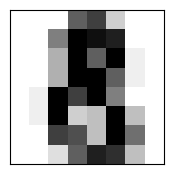

In [2]:
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)

def plot_image(x, ax=None):
    if ax is None: fig, ax = plt.subplots(figsize=(2, 2))
    im = ax.imshow(x.reshape((8, 8)),  cmap=plt.cm.binary, interpolation="nearest")
#     im.set_clim(0, 16)
    ax.set(xticks=[], yticks=[]);
    
plot_image(X[224])

In [3]:
from sklearn.decomposition import PCA

pca = PCA(n_components=15, whiten=False)
X_ = pca.fit_transform(X)

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KernelDensity
params = {"bandwidth": np.logspace(-1, 1, 20)}
grid = GridSearchCV(KernelDensity(), params)
grid.fit(X_)

GridSearchCV(estimator=KernelDensity(),
             param_grid={'bandwidth': array([ 0.1       ,  0.1274275 ,  0.16237767,  0.20691381,  0.26366509,
        0.33598183,  0.42813324,  0.54555948,  0.6951928 ,  0.88586679,
        1.12883789,  1.43844989,  1.83298071,  2.33572147,  2.97635144,
        3.79269019,  4.83293024,  6.15848211,  7.8475997 , 10.        ])})

In [7]:
kde = grid.best_estimator_
print("best bandwidth: {:.2f}".format(grid.best_estimator_.bandwidth))

best bandwidth: 3.79


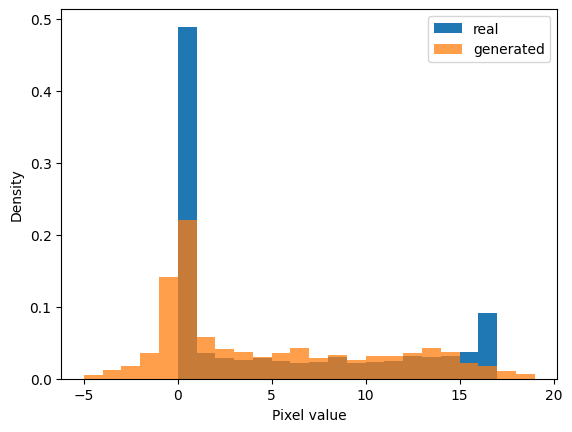

In [8]:
X_kde = kde.sample(10, random_state=0)
X_kde = pca.inverse_transform(X_kde)

plt.hist(X.ravel(), np.arange(-5, 20), density=True, label='real')
plt.hist(X_kde.ravel(), np.arange(-5, 20), density=True, alpha=0.75, label='generated')
plt.xlabel('Pixel value')
plt.ylabel('Density')
plt.legend();

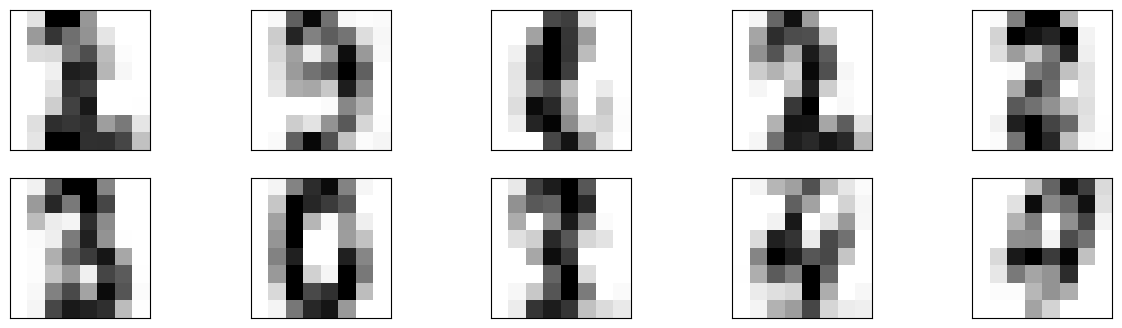

In [9]:
X_kde[X_kde<0]=0
X_kde[X_kde>16]=16

fig, axes = plt.subplots(2, 5, figsize=(15, 4))
for x, ax in zip(X_kde, axes.flat):
    plot_image(x, ax)

# Mixture model for 2D parameteric estimation